In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Books_Data_Clean.csv")
df.head()



,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [26]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,535.926660,1994.730426,4.012230,94817.793855,1832.644985,841.360638,4.844311,613.314172,9744.482656
std,308.769358,23.204719,0.246492,31473.890412,3947.885096,2279.579848,3.561712,369.628663,15350.021050
min,0.000000,1901.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,271.000000,1989.000000,3.860000,70701.000000,366.300000,0.000000,1.990000,291.000000,570.000000
50%,535.000000,2003.000000,4.030000,89204.000000,792.000000,273.240000,3.990000,596.000000,3942.000000
75%,802.000000,2010.000000,4.180000,113400.000000,1470.260000,714.756000,6.990000,933.000000,5427.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [25]:
df=df[df["Publishing Year"] >1900]


In [33]:
df.duplicated().sum()

np.int64(0)

In [11]:
numeric_cols=df.select_dtypes(include=["int","float"]).columns
corr_matrix=df[numeric_cols].corr()
print(corr_matrix)


                        index  Publishing Year  Book_average_rating  \
index                1.000000         0.015993            -0.019917   
Publishing Year      0.015993         1.000000             0.054553   
Book_average_rating -0.019917         0.054553             1.000000   
Book_ratings_count  -0.843338         0.000290             0.093033   
gross sales         -0.455475         0.008908            -0.042240   
publisher revenue   -0.350709         0.007629            -0.043510   
sale price           0.073490         0.028626             0.000290   
sales rank           0.999475         0.016796            -0.020217   
units sold           0.222006        -0.015231            -0.008516   

                     Book_ratings_count  gross sales  publisher revenue  \
index                         -0.843338    -0.455475          -0.350709   
Publishing Year                0.000290     0.008908           0.007629   
Book_average_rating            0.093033    -0.042240          -0

In [30]:
df.isnull().sum()

index                   0
Publishing Year         0
Book Name               0
Author                  0
language_code          47
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [32]:
df.dropna(subset="Book Name",inplace=True)

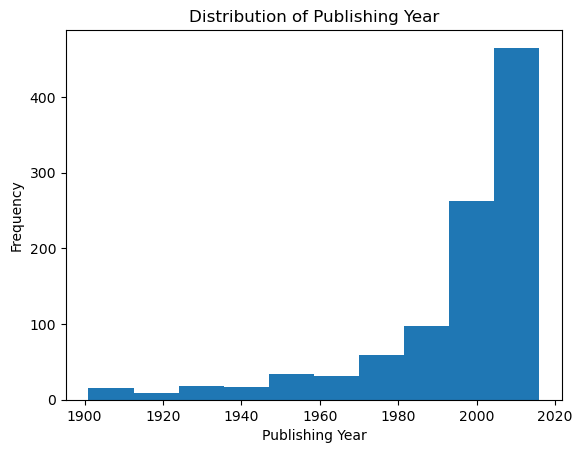

In [28]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

In [34]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

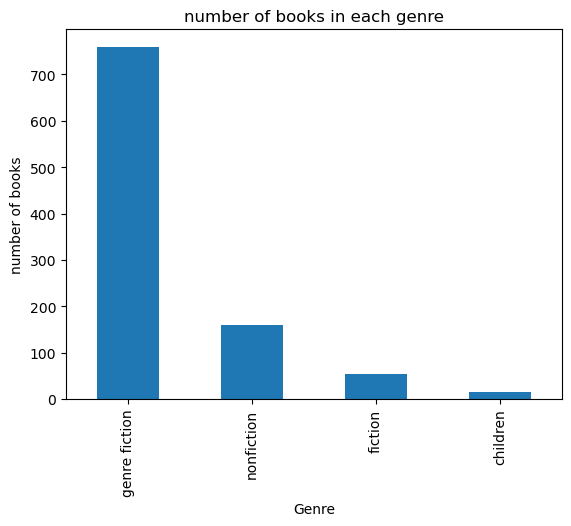

In [38]:
df["genre"].value_counts().plot(kind="bar")
plt.xlabel("Genre")
plt.ylabel("number of books")
plt.title("number of books in each genre")
plt.show()

In [48]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False).head(1)

Author
Bill Watterson    4.65
Name: Book_average_rating, dtype: float64

In [52]:
df.groupby("sale price")["sales rank"].mean().sort_values(ascending=False).head(2)

sale price
7.81     1249.0
12.59    1248.0
Name: sales rank, dtype: float64

In [61]:
df.groupby("Author_Rating")["Book_ratings_count"].var().sort_values(ascending=False).head()

Author_Rating
Famous          1.227555e+09
Intermediate    1.170331e+09
Novice          9.523157e+08
Excellent       4.419857e+08
Name: Book_ratings_count, dtype: float64

<Axes: xlabel='Author_Rating', ylabel='units sold'>

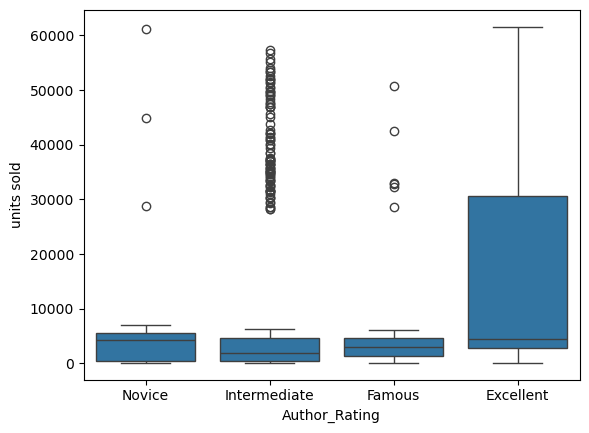

In [62]:
sns.boxplot(x="Author_Rating",y="units sold",data=df)

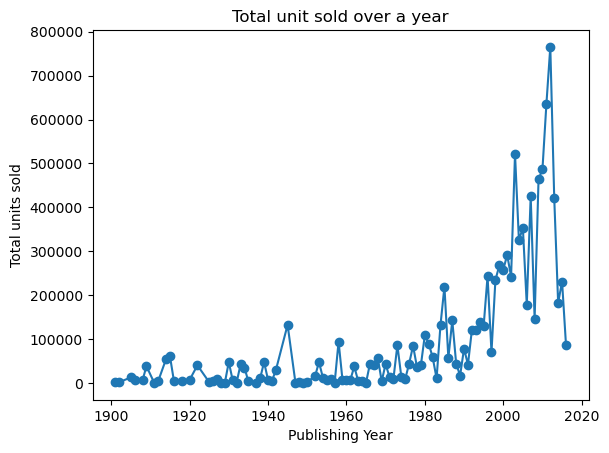

In [67]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line",marker="o")
plt.xlabel("Publishing Year")
plt.ylabel("Total units sold")
plt.title("Total unit sold over a year")
plt.show()